# **Housing Discrimination and Algorithmic Bias Analysis**

## **Name:** Tirth Laheri

## Overview

This notebook analyzes mortgage lending data to examine potential algorithmic bias in lending decisions. The analysis focuses on approval rates, interest rates, and denial reasons across applicant racial groups and neighborhoods with different covenant densities. The final section extends the analysis by comparing lending patterns between Hennepin County and Ramsey County using the original Minnesota HMDA dataset.

## Data Preparation

The merged mortgage and covenant dataset is loaded and explored before performing the algorithmic bias analysis. Basic exploratory data analysis is used to understand the structure of the data and identify any missing values that require preprocessing.

In [19]:
#data manipulation
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.style.use('ggplot')

### Dataset Overview

In [22]:
mortgage = pd.read_csv('data/mortgage_covenant_data.csv')

mortgage.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [23]:
mortgage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

### Summary Statistics

In [24]:
mortgage.describe(include='all')

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
count,100931.0,9.991500e+04,100931,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000,100931,11169
unique,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4
top,NaN,NaN,White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,Low (1-50)
freq,NaN,NaN,63627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67085,4537
mean,2023.0,2.708025e+10,NaN,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101,NaN,NaN
std,0.0,5.254319e+07,NaN,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673,NaN,NaN
min,2023.0,2.700177e+10,NaN,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN
25%,2023.0,2.703706e+10,NaN,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000,NaN,NaN
50%,2023.0,2.705311e+10,NaN,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000,NaN,NaN
75%,2023.0,2.712304e+10,NaN,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000,NaN,NaN


In [25]:
missing = mortgage.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
covenant_density,89762
interest_rate,22806
property_value,17440
income,12731
census_tract,1016


### Missing Values

In [26]:
mortgage['derived_race'].value_counts()

,count
derived_race,
White,63627
Race Not Available,22811
Asian,5905
Black or African American,5199
Joint,2427
American Indian or Alaska Native,709
2 or more minority races,135
Native Hawaiian or Other Pacific Islander,113
Free Form Text Only,5


In [27]:
mortgage['covenant_density'].value_counts(dropna=False)

,count
covenant_density,
NaN,89762
Low (1-50),4537
Very High (>200),3140
Medium (51-100),1772
High (101-200),1720


In [28]:
mortgage['was_approved'].value_counts()

,count
was_approved,
True,67085
False,33846


In [29]:
mortgage.groupby('covenant_density')['was_approved'].mean()

,was_approved
covenant_density,
High (101-200),0.692442
Low (1-50),0.661230
Medium (51-100),0.670429
Very High (>200),0.673885


In [30]:
mortgage['covenant_density'] = mortgage['covenant_density'].fillna('No Covenants')

In [31]:
mortgage['covenant_density'].value_counts()

,count
covenant_density,
No Covenants,89762
Low (1-50),4537
Very High (>200),3140
Medium (51-100),1772
High (101-200),1720


# Algorithmic Bias Analysis

This section examines lending outcomes that may reflect algorithmic bias. Loan approval rates, interest rates, and denial reasons are compared across applicant racial groups and neighborhoods with different covenant densities to identify patterns in mortgage lending decisions.

In [32]:
algorithmic = mortgage[mortgage['covenant_density'] != 'No Covenants'].copy()

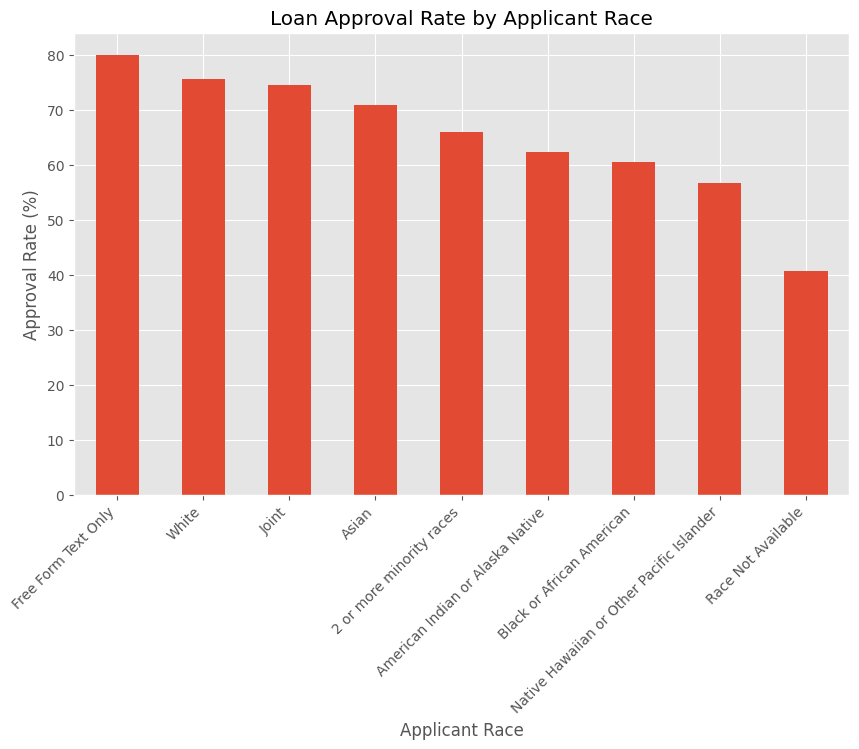

In [33]:
approval_by_race = (
    mortgage.groupby('derived_race')['was_approved']
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10,6))

approval_by_race.plot(kind='bar')

plt.ylabel('Approval Rate (%)')
plt.xlabel('Applicant Race')
plt.title('Loan Approval Rate by Applicant Race')

plt.xticks(rotation=45, ha='right')

plt.show()

### Loan Approval Rate by Applicant Race

Algorithmic bias happens when a decision-making system produces different outcomes for different groups because it learns patterns from historical data. Even if race is not directly used, factors like income, property value, and neighborhood characteristics can still influence the results.

This chart shows that approval rates vary across racial groups. White applicants have a higher approval rate than several minority groups, while Black or African American and Native Hawaiian or Other Pacific Islander applicants have lower approval rates. These differences do not prove bias on their own, but they suggest that historical inequalities in the data may still influence modern mortgage lending decisions.

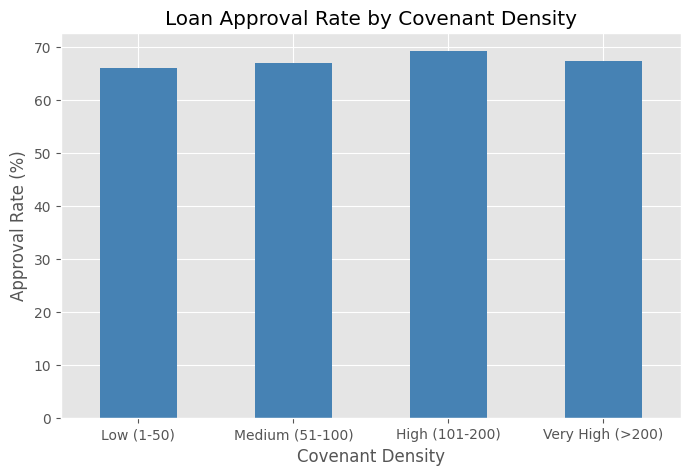

In [34]:
approval_density = (
    algorithmic.groupby('covenant_density')['was_approved']
    .mean()
    * 100
)

order = [
    'Low (1-50)',
    'Medium (51-100)',
    'High (101-200)',
    'Very High (>200)'
]

approval_density = approval_density.reindex(order)

plt.figure(figsize=(8,5))

approval_density.plot(kind='bar', color='steelblue')

plt.title('Loan Approval Rate by Covenant Density')
plt.xlabel('Covenant Density')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=0)

plt.show()

### Loan Approval Rate by Covenant Density

This chart compares mortgage approval rates across neighborhoods with different levels of historical racial covenants. Approval rates remain fairly consistent, ranging from about **66% to 69%** across all four groups. This suggests that covenant density alone does not have a strong impact on loan approval decisions, although it may still influence other factors used in the lending process.

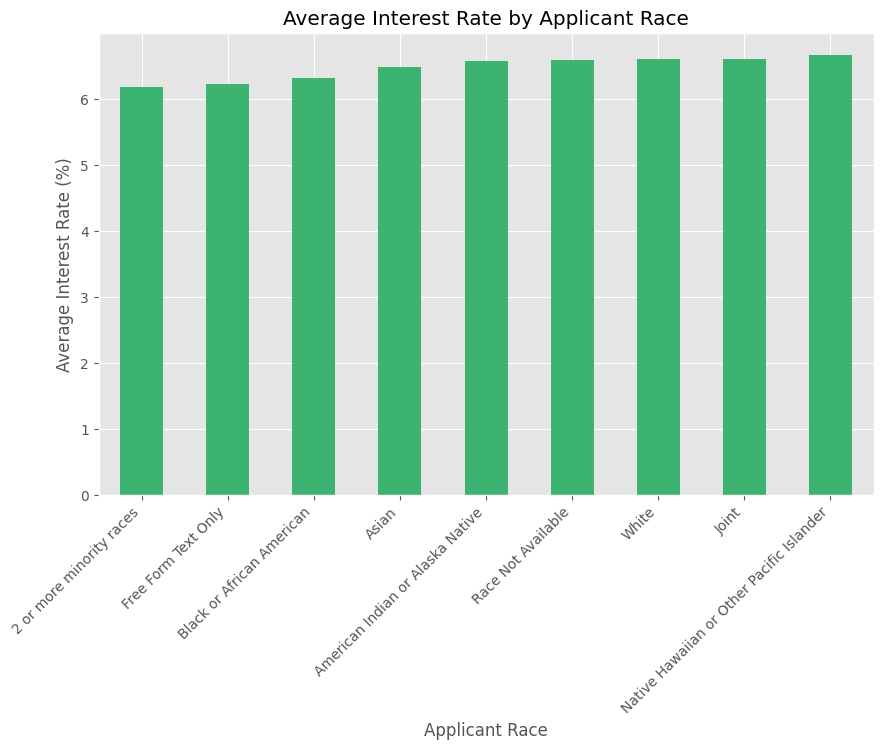

In [35]:
interest_by_race = (
    mortgage.groupby('derived_race')['interest_rate']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

interest_by_race.plot(kind='bar', color='mediumseagreen')

plt.title('Average Interest Rate by Applicant Race')
plt.xlabel('Applicant Race')
plt.ylabel('Average Interest Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.show()

### Average Interest Rate by Applicant Race

This chart compares the average interest rates offered to different racial groups. The average rates are fairly similar across all groups, ranging from approximately **6.2% to 6.7%**. While there are small differences, there is no clear evidence that one racial group consistently receives much higher interest rates than the others. This suggests that, based on this dataset, interest rates show less variation by race than loan approval rates.

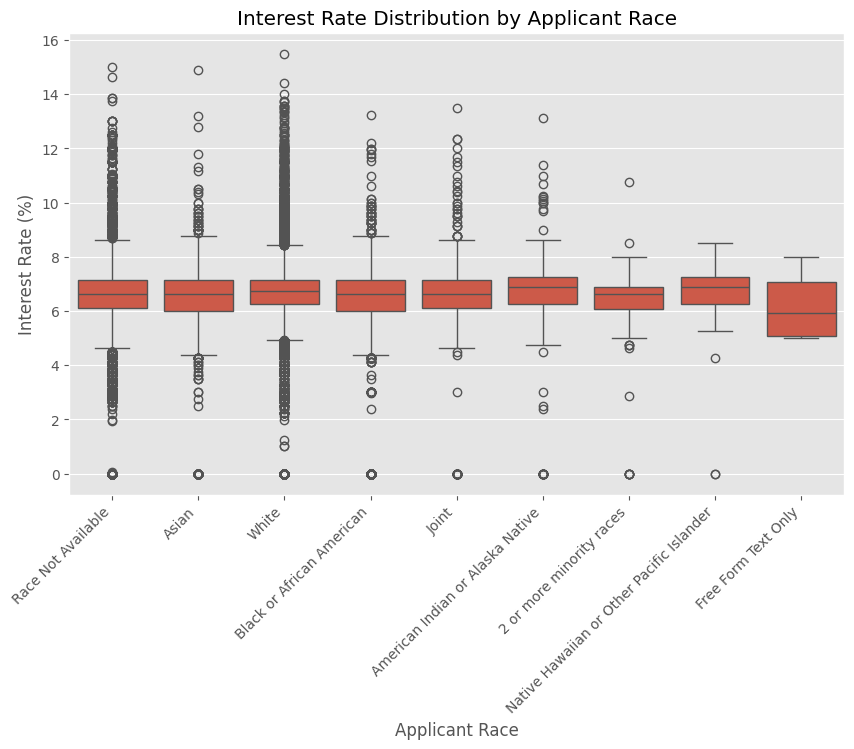

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=mortgage,
    x='derived_race',
    y='interest_rate'
)

plt.title('Interest Rate Distribution by Applicant Race')
plt.xlabel('Applicant Race')
plt.ylabel('Interest Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.show()

### Interest Rate Distribution by Applicant Race

This box plot compares the distribution of interest rates across different racial groups. Most applicants received interest rates between **6% and 7%**, and the median rates are similar across all groups. While there are some outliers, there is no clear evidence that one racial group consistently received much higher interest rates than the others. Compared to loan approval rates, interest rates appear to be more consistent across racial groups in this dataset.

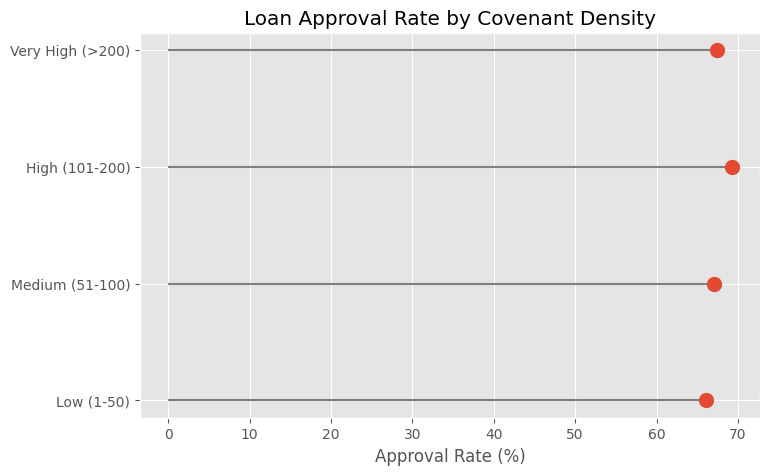

In [37]:
approval = (
    algorithmic.groupby('covenant_density')['was_approved']
    .mean()*100
).reindex([
    'Low (1-50)',
    'Medium (51-100)',
    'High (101-200)',
    'Very High (>200)'
])

plt.figure(figsize=(8,5))

plt.hlines(
    y=approval.index,
    xmin=0,
    xmax=approval.values,
    color='gray'
)

plt.plot(
    approval.values,
    approval.index,
    "o",
    markersize=10
)

plt.xlabel("Approval Rate (%)")
plt.title("Loan Approval Rate by Covenant Density")

plt.show()

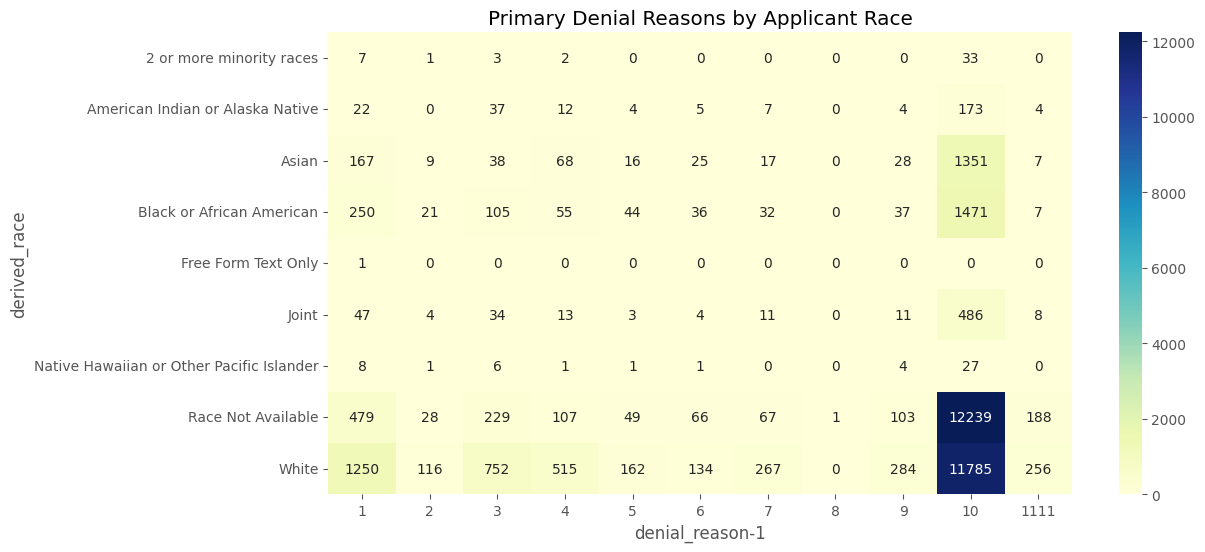

In [38]:
denied = mortgage[mortgage['was_approved']==False]

table = pd.crosstab(
    denied['derived_race'],
    denied['denial_reason-1']
)

plt.figure(figsize=(12,6))

sns.heatmap(
    table,
    cmap='YlGnBu',
    annot=True,
    fmt='d'
)

plt.title("Primary Denial Reasons by Applicant Race")

plt.show()

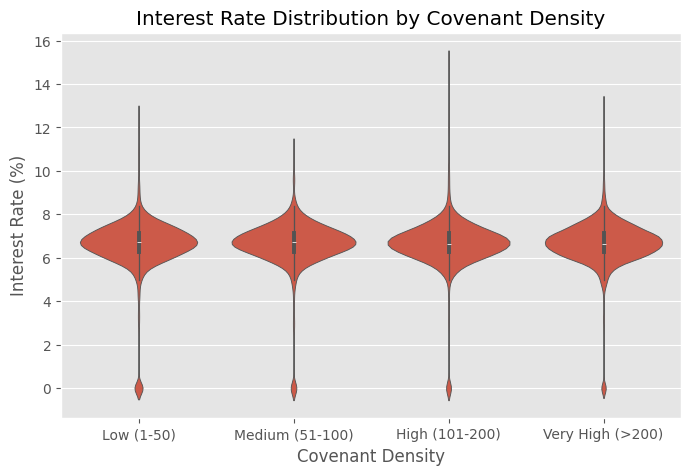

In [41]:
violin_data = mortgage[mortgage['covenant_density'] != 'No Covenants']

plt.figure(figsize=(8,5))

sns.violinplot(
    data=violin_data,
    x='covenant_density',
    y='interest_rate',
    order=[
        'Low (1-50)',
        'Medium (51-100)',
        'High (101-200)',
        'Very High (>200)'
    ]
)

plt.title('Interest Rate Distribution by Covenant Density')
plt.xlabel('Covenant Density')
plt.ylabel('Interest Rate (%)')

plt.show()

### Interest Rate Distribution by Covenant Density

This violin plot compares the distribution of mortgage interest rates across neighborhoods with different levels of historical racial covenants. Most interest rates are clustered between **6% and 7%**, and the distributions are very similar across all four groups. Although a few outliers are present, there is no clear evidence that applicants from neighborhoods with higher covenant density consistently receive higher interest rates.

In [42]:
#denial reason labels
reason_map = {
    1: 'Debt-to-income',
    2: 'Employment',
    3: 'Credit History',
    4: 'Collateral',
    5: 'Cash Reserves',
    6: 'Unverified Info',
    7: 'Incomplete Application',
    8: 'Mortgage Insurance',
    9: 'Other',
    10: 'Not Applicable',
    1111: 'Exempt'
}

mortgage['denial_reason'] = mortgage['denial_reason-1'].map(reason_map)

In [43]:
denied = mortgage[mortgage['was_approved'] == False].copy()

In [44]:
denied = denied[denied['denial_reason'] != 'Not Applicable']

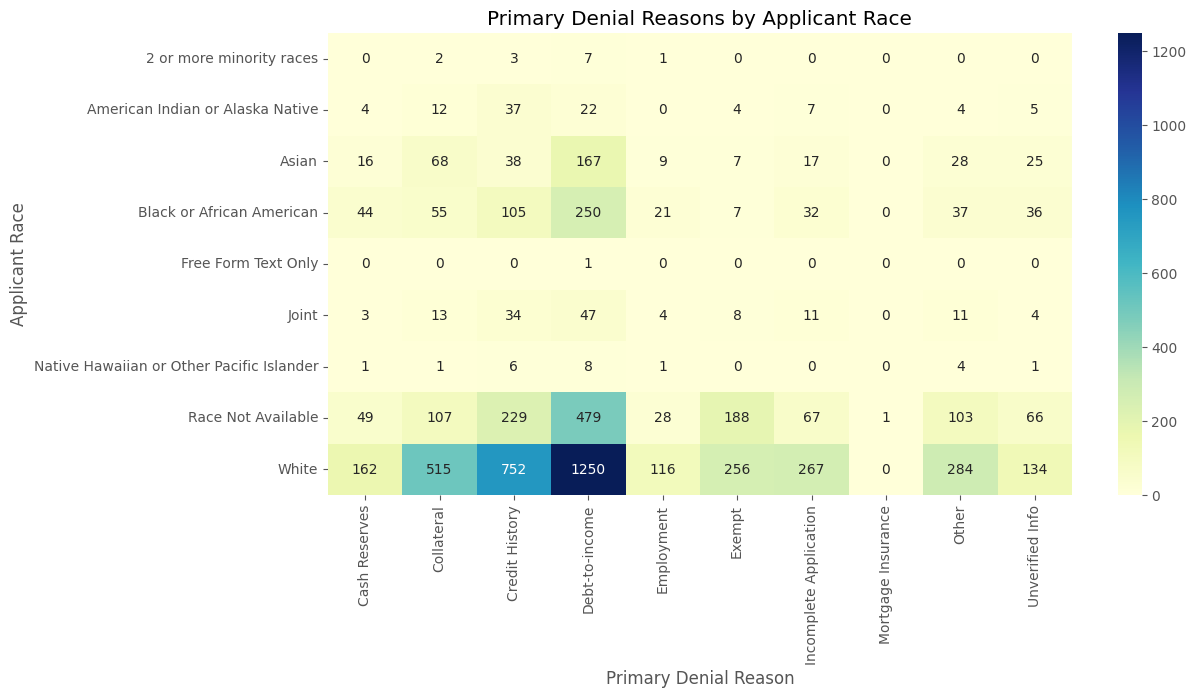

In [45]:
plt.figure(figsize=(12,6))

heatmap_data = pd.crosstab(
    denied['derived_race'],
    denied['denial_reason']
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Primary Denial Reasons by Applicant Race')
plt.xlabel('Primary Denial Reason')
plt.ylabel('Applicant Race')

plt.show()

### Primary Denial Reasons by Applicant Race

This heatmap shows the most common reasons for mortgage application denials across different racial groups. Debt-to-income ratio and credit history are the most frequent denial reasons for most applicants, followed by collateral and incomplete applications. While the number of denials varies across racial groups, the overall pattern of denial reasons is similar. Since this chart shows counts rather than percentages, larger groups naturally have higher values.

# Ramsey County Extension

This section extends the analysis by comparing lending patterns between Hennepin County and Ramsey County using the original 2023 Minnesota HMDA dataset (`state_MN.csv`). The goal is to determine whether the patterns observed in Hennepin County are similar in Ramsey County.

In [46]:
#load ramsey dataset

state_MN = pd.read_csv("data/state_MN.csv")

/tmp/ipykernel_967/3262346989.py:3: DtypeWarning: Columns (22,23,24,26,27,28,29,30,31,32,33,38,44) have mixed types. Specify dtype option on import or set low_memory=False.
  state_MN = pd.read_csv("state_MN.csv")


In [47]:
#first few rows

state_MN.head()

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,loan_amount,loan_to_value_ratio,interest_rate,rate_spread,hoepa_status,total_loan_costs,total_points_and_fees,origination_charges,discount_points,lender_credits,loan_term,prepayment_penalty_term,intro_rate_period,negative_amortization,interest_only_payment,balloon_payment,other_nonamortizing_features,property_value,construction_method,occupancy_type,manufactured_home_secured_property_type,manufactured_home_land_property_interest,total_units,multifamily_affordable_units,income,debt_to_income_ratio,applicant_credit_score_type,co-applicant_credit_score_type,applicant_ethnicity-1,applicant_ethnicity-2,applicant_ethnicity-3,applicant_ethnicity-4,applicant_ethnicity-5,co-applicant_ethnicity-1,co-applicant_ethnicity-2,co-applicant_ethnicity-3,co-applicant_ethnicity-4,co-applicant_ethnicity-5,applicant_ethnicity_observed,co-applicant_ethnicity_observed,applicant_race-1,applicant_race-2,applicant_race-3,applicant_race-4,applicant_race-5,co-applicant_race-1,co-applicant_race-2,co-applicant_race-3,co-applicant_race-4,co-applicant_race-5,applicant_race_observed,co-applicant_race_observed,applicant_sex,co-applicant_sex,applicant_sex_observed,co-applicant_sex_observed,applicant_age,co-applicant_age,applicant_age_above_62,co-applicant_age_above_62,submission_of_application,initially_payable_to_institution,aus-1,aus-2,aus-3,aus-4,aus-5,denial_reason-1,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2023,549300VZVN841I2ILS84,33460,MN,27053.0,2.705302e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,Race Not Available,Male,1,2,2,2,1,1,2,2,2,305000.0,95.00000,6.500,0.576,2,16722.90,NaN,8821.90,7231.90,40.80,360,NaN,NaN,2,2,2,2,325000,1,1,3,5,1,NaN,65.0,46,3,10,3.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,6.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,1,5,2,4,<25,9999,No,NaN,1,1,3,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,4342,38.48,124300,83.64,1444,1506,62
1,2023,549300VZVN841I2ILS84,33460,MN,27003.0,2.700305e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,1,1,1,1,1,1,2,2,2,285000.0,97.00000,6.450,0.375,2,9733.71,NaN,7225.71,5735.71,9.00,360,NaN,NaN,2,2,2,2,295000,1,1,3,5,1,NaN,72.0,41,1,10,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,4,5.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,2,4,1,5,2,4,<25,9999,No,NaN,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,3008,21.74,124300,86.21,965,1168,63
2,2023,549300VZVN841I2ILS84,33460,MN,27037.0,2.703706e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Joint,1,3,2,1,1,1,2,2,2,365000.0,72.80000,7.490,0.890,2,4182.27,NaN,1555.52,65.52,575.00,360,NaN,NaN,2,2,2,2,505000,1,1,3,5,1,NaN,175.0,42,1,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,2,2,1,2,2,2,25-34,25-34,No,No,1,1,2,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,6341,18.62,124300,130.45,2012,2268,28
3,2023,549300VZVN841I2ILS84,33460,MN,27003.0,2.700305e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Asian,Joint,1,6,2,1,1,1,2,2,2,315000.0,98.50700,7.000,0.458,2,6794.50,NaN,4610.00,NaN,39.00,360,NaN,NaN,2,2,2,2,335000,1,1,3,5,1,NaN,108.0,42,3,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,2.0,22.0,NaN,NaN,NaN,2.0,22.0,NaN,NaN,NaN,2,2,1,2,2,2,55-64,35-44,No,No,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,6769,22.37,124300,97.44,1574,1705,31
4,2023,549300VZVN841I2ILS84,99999,MN,27113.0,2.711309e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or 

In [48]:
#dataset shape

state_MN.shape

(175162, 99)

In [49]:
#column names

state_MN.columns

Index(['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code',
       'census_tract', 'conforming_loan_limit', 'derived_loan_product_type',
       'derived_dwelling_category', 'derived_ethnicity', 'derived_race',
       'derived_sex', 'action_taken', 'purchaser_type', 'preapproval',
       'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage',
       'open-end_line_of_credit', 'business_or_commercial_purpose',
       'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread',
       'hoepa_status', 'total_loan_costs', 'total_points_and_fees',
       'origination_charges', 'discount_points', 'lender_credits', 'loan_term',
       'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization',
       'interest_only_payment', 'balloon_payment',
       'other_nonamortizing_features', 'property_value', 'construction_method',
       'occupancy_type', 'manufactured_home_secured_property_type',
       'manufactured_home_land_property_interest', 'total_

In [50]:
#dataset information

state_MN.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175162 entries, 0 to 175161
Data columns (total 99 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   activity_year                             175162 non-null  int64  
 1   lei                                       175162 non-null  object 
 2   derived_msa-md                            175162 non-null  int64  
 3   state_code                                175162 non-null  object 
 4   county_code                               173850 non-null  float64
 5   census_tract                              173504 non-null  float64
 6   conforming_loan_limit                     174358 non-null  object 
 7   derived_loan_product_type                 175162 non-null  object 
 8   derived_dwelling_category                 175162 non-null  object 
 9   derived_ethnicity                         175162 non-null  object 
 10  derived_race        

In [51]:
#missing values

state_MN.isnull().sum()

,0
activity_year,0
lei,0
derived_msa-md,0
state_code,0
county_code,1312
census_tract,1658
conforming_loan_limit,804
derived_loan_product_type,0
derived_dwelling_category,0
derived_ethnicity,0


In [52]:
#hennepin and ramsey counties

hennepin = state_MN[state_MN["county_code"] == 27053].copy()

ramsey = state_MN[state_MN["county_code"] == 27123].copy()

In [53]:
print("Hennepin records:", len(hennepin))
print("Ramsey records:", len(ramsey))

Hennepin records: 38052
Ramsey records: 14481


In [54]:
#create approval variable

hennepin["approved"] = hennepin["action_taken"] == 1
ramsey["approved"] = ramsey["action_taken"] == 1

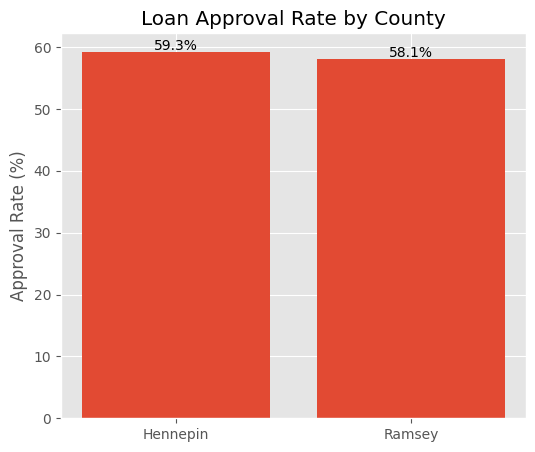

In [55]:
#approval rates

hennepin_rate = hennepin["approved"].mean() * 100
ramsey_rate = ramsey["approved"].mean() * 100

approval = pd.DataFrame({
    "County": ["Hennepin", "Ramsey"],
    "Approval Rate (%)": [hennepin_rate, ramsey_rate]
})

plt.figure(figsize=(6,5))

plt.bar(
    approval["County"],
    approval["Approval Rate (%)"]
)

for i, value in enumerate(approval["Approval Rate (%)"]):
    plt.text(i, value+0.3, f"{value:.1f}%", ha="center")

plt.title("Loan Approval Rate by County")
plt.ylabel("Approval Rate (%)")

plt.show()

### Loan Approval Rate by County

This chart compares the overall mortgage loan approval rates between Hennepin County and Ramsey County. Hennepin County has a slightly higher approval rate (59.3%) than Ramsey County (58.1%), but the difference is relatively small. This suggests that overall lending outcomes are generally similar across the two counties, with only minor variation in approval rates.

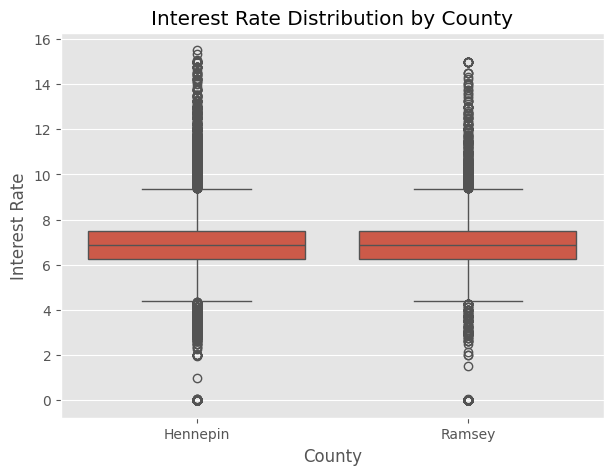

In [56]:
#interest rate comparison

hennepin_interest = pd.to_numeric(
    hennepin["interest_rate"],
    errors="coerce"
)

ramsey_interest = pd.to_numeric(
    ramsey["interest_rate"],
    errors="coerce"
)

interest = pd.DataFrame({
    "Interest Rate": pd.concat([
        hennepin_interest,
        ramsey_interest
    ], ignore_index=True),
    "County": (["Hennepin"] * len(hennepin_interest)) +
              (["Ramsey"] * len(ramsey_interest))
})

plt.figure(figsize=(7,5))

sns.boxplot(
    data=interest,
    x="County",
    y="Interest Rate"
)

plt.title("Interest Rate Distribution by County")

plt.show()

### Interest Rate Distribution by County

This box plot compares the distribution of mortgage interest rates between Hennepin County and Ramsey County. Both counties have very similar median interest rates and comparable distributions, indicating that borrowers in the two counties generally received similar mortgage interest rates. Although there are several outliers in both counties, the overall lending patterns appear consistent.

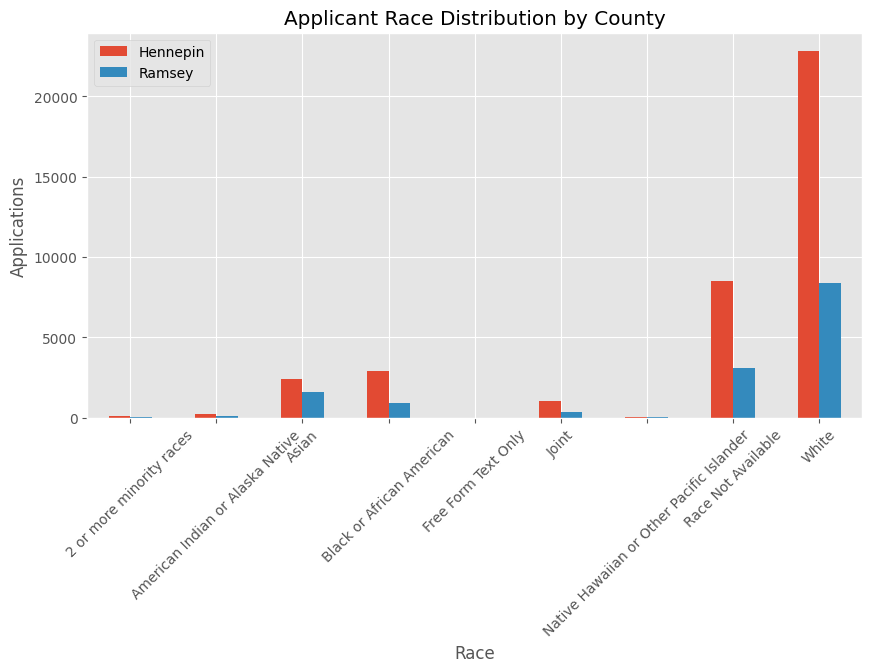

In [57]:
#race distribution

race = pd.crosstab(
    state_MN["derived_race"],
    state_MN["county_code"]
)

race = race[[27053.0,27123.0]]

race.columns = ["Hennepin","Ramsey"]

race.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Applicant Race Distribution by County")
plt.xlabel("Race")
plt.ylabel("Applications")

plt.xticks(rotation=45)

plt.show()

### Applicant Race Distribution by County

This chart compares the number of mortgage applications submitted by different racial groups in Hennepin County and Ramsey County. White applicants represent the largest group in both counties, followed by applicants identifying as Race Not Available, Asian, and Black or African American. Because Hennepin County has a larger number of total mortgage applications than Ramsey County, it also has higher counts across most racial groups. Therefore, this chart reflects differences in application volume as well as demographic composition.

## Challenges and Limitations

The county comparison uses HMDA data, which does not include all factors considered during mortgage underwriting, such as complete credit history, employment stability, or lender-specific decision criteria. Additionally, Hennepin County has a substantially larger number of mortgage applications than Ramsey County, making direct comparisons of raw counts less informative. As a result, the analysis identifies patterns and differences between counties but cannot determine the underlying causes of those differences.

# Conclusion

The analysis identified patterns in mortgage lending across applicant groups, neighborhoods, and counties. While approval rates and interest rates were generally similar across many groups, some differences in lending outcomes were observed. The comparison between Hennepin County and Ramsey County showed similar overall lending patterns, although differences in applicant demographics and approval rates were present. Overall, the analysis provides insight into potential patterns of algorithmic bias while recognizing the limitations of the available data.